# **Контест 1**
# **Линейная регрессия**
*Выполнил: Ефименко Кирилл М8О-309Б-22*

## Подключим необходимые библиотеки

In [1]:
!pip install fancyimpute
!pip install dirty_cat

  Preparing metadata (setup.py) ... - done
  Preparing metadata (setup.py) ... - \ done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.5/297.5 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 39.1 MB/s eta 0:00:00
  Created wheel for fancyimpute: filename=fancyimpute-0.7.0-py3-none-any.whl size=29881 sha256=48557d7f3a88aa532272daa66365d7465efe0afe708f4cf15f8c72d10541e3f1
  Stored in directory: /root/.cache/pip/wheels/7b/0c/d3/ee82d1fbdcc0858d96434af108608d01703505d453720c84ed
  Created wheel for knnimpute: filename=knnimpute-0.1.0-py3-none-any.whl size=11330 sha256=769dbed44ddd6bc6211668e383bdc9da6f711137992711953936a3e0a9769c1c
  Stored in d

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from fancyimpute import IterativeImputer, KNN
import itertools
from dirty_cat import TargetEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.figure_factory as ff

## Загрузка датасета

In [3]:
df_train = pd.read_csv('/kaggle/input/mai-ml-contest-1/train.csv')
df_test = pd.read_csv('/kaggle/input/mai-ml-contest-1/test.csv')

## Изучение данных


Посмотрим размер пространства

In [4]:
df_train.shape

(11017, 36)

Посмотрим типы данных

In [5]:
df_train.dtypes

ApplicationDate                object
Age                           float64
AnnualIncome                  float64
CreditScore                   float64
LoanAmount                    float64
LoanDuration                  float64
MaritalStatus                  object
NumberOfDependents            float64
HomeOwnershipStatus            object
MonthlyDebtPayments           float64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines       float64
NumberOfCreditInquiries       float64
DebtToIncomeRatio             float64
BankruptcyHistory             float64
LoanPurpose                    object
PreviousLoanDefaults          float64
PaymentHistory                float64
LengthOfCreditHistory         float64
SavingsAccountBalance         float64
CheckingAccountBalance        float64
TotalAssets                   float64
TotalLiabilities              float64
MonthlyIncome                 float64
UtilityBillsPaymentHistory    float64
JobTenure                     float64
EmploymentSt

Мы видим, что есть категориальные признаки, обратим на них внимание, впоследствии закодируем их

Посмотрим на распределение целевой переменной от даты

In [6]:
fig1 = px.histogram(df_train, x="ApplicationDate", y="RiskScore",
                    histfunc='count',
                    template='presentation',
                    title='Application Date distribution')
fig1.show(renderer='iframe')

По графику видно, что кол-во наблюдений на каждую дату примерно одинаковое.


---



Изучим распределение целевой переменной

In [7]:
fig = px.histogram(df_train['RiskScore'],
                   x='RiskScore',
                   title='RiskScore distribution with outliers',
                   template='presentation',
                   nbins=31)
fig.show(renderer='iframe')

По графику видно, что присутствуют выбросы. Удалим их. И еще раз посмотри на распределение.

In [8]:
q03, q97 = df_train['RiskScore'].quantile(q=0.03), df_train['RiskScore'].quantile(q=0.97)

df_train = df_train[df_train['RiskScore'] > q03]
df_train = df_train[df_train['RiskScore'] < q97]
df_train[['RiskScore']].describe(percentiles=[0.01, 0.03, 0.1, 0.5, 0.75, 0.90, 0.97, 0.99])

,RiskScore
count,9857.000000
mean,48.076275
std,16.396497
min,24.326957
1%,25.192915
3%,26.542754
10%,29.059344
50%,44.118758
75%,64.524149
90%,71.257686


In [9]:
tg_dist = px.histogram(df_train, x="RiskScore", nbins=61,
                      template='presentation',
                      title='Risk score disribution without outliers',)
tg_dist.show(renderer='iframe')

После удаления выбросов целевой переменной распределение изменилось. Это хорошо отразится на предсказании модели, особенно при оценке MSE.

Посмотрим на зависимость значения целевой переменной от даты.

In [10]:
fig1 = px.histogram(df_train, x="ApplicationDate",
                    y="RiskScore",
                    hover_data=df_train.columns,
                    histfunc='avg',
                    template='presentation',
                    title='AVG Risk score on date',
                    nbins=61)
fig1.show(renderer='iframe')

Видно, что значения RiskScore не зависят от ApplicationDate


---



Удалим дату


In [11]:
df_train.drop(['ApplicationDate'], axis=1, inplace=True)
df_test.drop(['ApplicationDate'], axis=1, inplace=True)

Выведем категориальные фичи и посмотри на их кол-во по каждой категории.

Мы видим 5 категориальных признаков, которые впоследствии необходимо будет закодировать.

In [12]:
cat_features = df_train.select_dtypes(object).columns
for feature in cat_features:
  print(df_train[feature].value_counts(), end='\n-----\n-----\n')

MaritalStatus
Married     4800
Single      3045
Divorced    1484
Widowed      528
Name: count, dtype: int64
-----
-----
HomeOwnershipStatus
Mortgage    3917
Rent        2963
Own         1999
Other        978
Name: count, dtype: int64
-----
-----
LoanPurpose
Home                  2813
Debt Consolidation    2315
Auto                  1889
Education             1492
Other                  884
Name: count, dtype: int64
-----
-----
EmploymentStatus
Employed         8537
Self-Employed     922
Unemployed        398
Name: count, dtype: int64
-----
-----
EducationLevel
High School    3981
Bachelor       2906
Associate      1944
Master          704
Doctorate       322
Name: count, dtype: int64
-----
-----


Построим ***boxplot*** RiskScore на каждую категорию EmploymentStatus

In [13]:
fig1 = px.box(df_train, y="RiskScore", x="EmploymentStatus",
                   hover_data=df_train.columns,
                    title='Risk Score of Employment Status',
              template='presentation')
fig1.show(renderer='iframe')

Видим, что ср. значения Risk Score по группа трудоустройства примерно одинаковы.

---

Построим аналогичные графики для других категорий.

In [14]:
fig = px.box(df_train, y="RiskScore", x="EducationLevel",
                   hover_data=df_train.columns,
                    title='Risk Score of Education Level',
             template='presentation')
fig.show(renderer='iframe')

In [15]:
fig = px.box(df_train, y="RiskScore", x="LoanPurpose",
                   hover_data=df_train.columns,
                    title='Risk Score of Loan Purpose',
             template='presentation')
fig.show(renderer='iframe')

In [16]:
fig = px.box(df_train, y="RiskScore", x="MaritalStatus",
                   hover_data=df_train.columns,
                    title='Risk Score of Marital Status',
             template='presentation')
fig.show(renderer='iframe')

In [17]:
fig = px.box(df_train, y="RiskScore", x="HomeOwnershipStatus",
                   hover_data=df_train.columns,
                    title='Risk Score of Home Ownership Status',
             template='presentation')
fig.show(renderer='iframe')

Мы видим, что все значения *RiskScore* одинаково распределены от-но всех катеориальных признаков.

посмотрим на корреляции признаков между собой и относительно целевой переменной

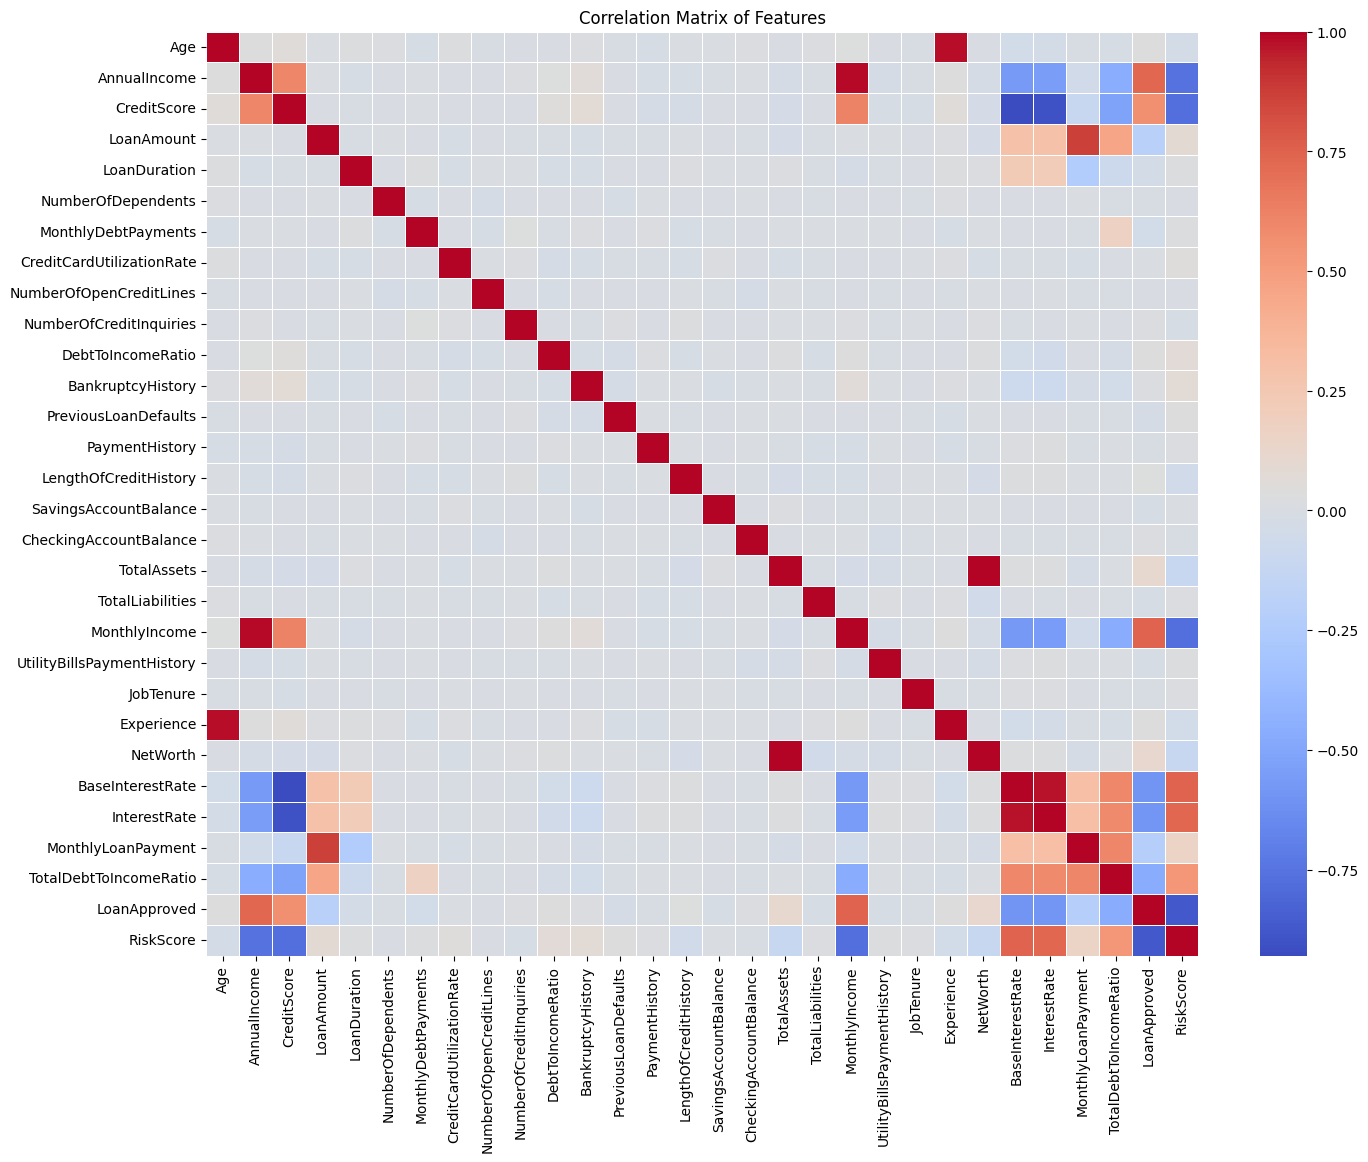

In [18]:
correlation_matrix = df_train.select_dtypes(float).corr()

plt.figure(figsize=(16, 12))

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)

plt.title('Correlation Matrix of Features')
plt.show()

мы видим некоторые зависимости между признаками, изучим более подробно признаки, которые хорошо коррелируют с RiskScore

Построим графики распределения непрерывных величин, изучим наличие выбросов

Построим зависимость RiskScore от CreditScore для оценки влияния кредитного рейтинга на кредитный риск

In [19]:
fig = px.scatter(df_train, x='CreditScore',
                 y='RiskScore',
                 opacity=1,
                 template='presentation',
                 trendline='lowess',
                 trendline_color_override='darkblue',
                 title='RiskScore of CreditScore trend line')
fig.show(renderer='iframe')

Мы видим некоторую зависимость целевой переменной от кредитноо рейтинга, изучим распределение кредитного рейтинга на тестовой и обучающей выборке

Теперь посмотрим на распределение CreditScore

In [20]:
tg_dist = px.histogram(df_train, x="CreditScore", nbins=31,
                      template='presentation',
                      title='Credit score disribution on train')
tg_dist.show(renderer='iframe')

Видим, что преобладают пороговые значения признака. Посмотрим на тестовую выборку.

In [21]:
tg_dist = px.histogram(df_test, x="CreditScore", nbins=31,
                      template='presentation',
                      title='Credit score disribution on test')
tg_dist.show(renderer='iframe')

На тестовой выборке видим такое же распределение. Следовательно не будем трогать эти значения. Обратим на это внимание. Возможно стоит прологарифмировать данный признак перед обучением модели.

Изучим другие признаки

In [22]:
fig = px.scatter(df_train, x='AnnualIncome',
                 y='RiskScore',
                 opacity=1,
                 template='presentation',
                 trendline='lowess',
                 trendline_color_override='darkblue',
                 title='RiskScore of AnnualIncome trend line')
fig.show(renderer='iframe')

Видно некоторую нелинейную зависимость между годовым доходом и кредитным риском. Также видно некоторое кол-во выбросов в сторону увеличения годового дохода. Посмотрим есть ли данные выбросы на тестовой выборке.

In [23]:
tg_dist = px.box(df_test, y="AnnualIncome",
                      template='presentation',
                      title='Annual income disribution on test')
tg_dist.show(renderer='iframe')

На тестовой выборке такие же выбросы, поэтому просто прологарифмируем этот признак, для уменьшения влияния выбросов.

Изучим влияние базовой процентной ставки на RiskScore

In [24]:
fig = px.scatter(df_train, x='TotalDebtToIncomeRatio',
                 y='RiskScore',
                 opacity=0.4,
                 template='presentation',
                 trendline='lowess',
                 trendline_color_override='darkblue',
                 title='RiskScore of TotalDebtToIncomeRatio trend line')
fig.show(renderer='iframe')

In [25]:
fig = px.scatter(df_train, x='BaseInterestRate',
                 y='RiskScore',
                 opacity=0.4,
                 template='presentation',
                 trendline='lowess',
                 trendline_color_override='darkblue',
                 title='RiskScore of BaseInterestRate trend line')
fig.show(renderer='iframe')

Данный признак точно стоит прологарифмировать, так как он по графику видно, что RiskScore почти логарифмически зависит от TotalDebtToIncomeRatio

In [26]:
fig = px.scatter(df_train, x='LoanApproved',
                 y='RiskScore',
                 opacity=0.4,
                 template='presentation',
                 trendline='lowess',
                 trendline_color_override='darkblue',
                 title='RiskScore of LoanApproved trend line')
fig.show(renderer='iframe')

Посмотрим наличие пропущенных значений

In [27]:
df_train.isna().sum()

Age                             0
AnnualIncome                    0
CreditScore                   464
LoanAmount                    464
LoanDuration                    0
MaritalStatus                   0
NumberOfDependents              0
HomeOwnershipStatus             0
MonthlyDebtPayments           464
CreditCardUtilizationRate       0
NumberOfOpenCreditLines         0
NumberOfCreditInquiries         0
DebtToIncomeRatio               0
BankruptcyHistory             464
LoanPurpose                   464
PreviousLoanDefaults            0
PaymentHistory                  0
LengthOfCreditHistory           0
SavingsAccountBalance           0
CheckingAccountBalance        464
TotalAssets                   464
TotalLiabilities                0
MonthlyIncome                   0
UtilityBillsPaymentHistory      0
JobTenure                       0
EmploymentStatus                0
EducationLevel                  0
Experience                      0
NetWorth                      464
BaseInterestRa

Посмотри на процетное соотношение пропусков

In [28]:
df_train.isnull().mean()*100

Age                           0.000000
AnnualIncome                  0.000000
CreditScore                   4.707315
LoanAmount                    4.707315
LoanDuration                  0.000000
MaritalStatus                 0.000000
NumberOfDependents            0.000000
HomeOwnershipStatus           0.000000
MonthlyDebtPayments           4.707315
CreditCardUtilizationRate     0.000000
NumberOfOpenCreditLines       0.000000
NumberOfCreditInquiries       0.000000
DebtToIncomeRatio             0.000000
BankruptcyHistory             4.707315
LoanPurpose                   4.707315
PreviousLoanDefaults          0.000000
PaymentHistory                0.000000
LengthOfCreditHistory         0.000000
SavingsAccountBalance         0.000000
CheckingAccountBalance        4.707315
TotalAssets                   4.707315
TotalLiabilities              0.000000
MonthlyIncome                 0.000000
UtilityBillsPaymentHistory    0.000000
JobTenure                     0.000000
EmploymentStatus         

In [29]:
df_test.dtypes

ID                              int64
Age                             int64
AnnualIncome                    int64
CreditScore                     int64
LoanAmount                      int64
LoanDuration                    int64
MaritalStatus                  object
NumberOfDependents              int64
HomeOwnershipStatus            object
MonthlyDebtPayments             int64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines         int64
NumberOfCreditInquiries         int64
DebtToIncomeRatio             float64
BankruptcyHistory               int64
LoanPurpose                    object
PreviousLoanDefaults            int64
PaymentHistory                  int64
LengthOfCreditHistory           int64
SavingsAccountBalance           int64
CheckingAccountBalance          int64
TotalAssets                     int64
TotalLiabilities                int64
MonthlyIncome                 float64
UtilityBillsPaymentHistory    float64
JobTenure                       int64
EmploymentSt

Закодируем категориальные признаки без пропусков.

In [30]:
def mean_target_encode(df, features: list[str], df_test, y, cv=5, random_state=None):
  enc = TargetEncoder()
  for feature in features:
    enc = enc.fit(df[feature].values.reshape(-1, 1), y.values)
    df[feature] = enc.transform(df[feature].values.reshape(-1, 1))
    df_test[feature] = enc.transform(df_test[feature].values.reshape(-1, 1))


# Loan purpose we are going to encode after imputing
mean_target_encoded_features = ['MaritalStatus', 'HomeOwnershipStatus', 'EmploymentStatus', 'EducationLevel']
mean_target_encode(df_train, mean_target_encoded_features, df_test, df_train['RiskScore'], cv=20, random_state=90)

In [31]:
def label_encode(df, features: list[str], df_test):
  le = LabelEncoder()
  for feature in features:
    le = le.fit(df[feature].values)
    df[feature] = le.transform(df[feature])
    df_test[feature] = le.transform(df_test[feature])

# label_encoded_features =  ['EducationLevel']
# label_encode(df_train, label_encoded_features, df_test)

In [32]:
df_train_mist = df_train[df_train['LoanPurpose'].isnull()].copy(deep=True)
df_train.dropna(subset=['LoanPurpose'], axis=0, inplace=True)
mean_target_encode(df_train, ['LoanPurpose'], df_test, df_train['RiskScore'], cv=20, random_state=90)
df_train = pd.concat([df_train, df_train_mist])

/tmp/ipykernel_17/272709312.py:4: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [33]:
df_train.isnull().mean()*100

Age                           0.000000
AnnualIncome                  0.000000
CreditScore                   4.707315
LoanAmount                    4.707315
LoanDuration                  0.000000
MaritalStatus                 0.000000
NumberOfDependents            0.000000
HomeOwnershipStatus           0.000000
MonthlyDebtPayments           4.707315
CreditCardUtilizationRate     0.000000
NumberOfOpenCreditLines       0.000000
NumberOfCreditInquiries       0.000000
DebtToIncomeRatio             0.000000
BankruptcyHistory             4.707315
LoanPurpose                   4.707315
PreviousLoanDefaults          0.000000
PaymentHistory                0.000000
LengthOfCreditHistory         0.000000
SavingsAccountBalance         0.000000
CheckingAccountBalance        4.707315
TotalAssets                   4.707315
TotalLiabilities              0.000000
MonthlyIncome                 0.000000
UtilityBillsPaymentHistory    0.000000
JobTenure                     0.000000
EmploymentStatus         

Заполним пропуски в числовых признаках

In [34]:
def MICE_impute(columns):
  MICE_imputer = IterativeImputer()
  df_train[columns] = MICE_imputer.fit_transform(df_train[columns])


def KNN_impute(columns):
  knn_imputer = KNN(k=3)
  df_train[columns] = knn_imputer.fit_transform(df_train[columns])


features = df_train.select_dtypes(float).columns
MICE_impute(features)
# KNN_impute(features)

## Добавим новых фичей

Предполагая, что Credit Score несет большой вклад в риск. Будем комбинировать его с другими фичами и искать нелинейные зависимости между ним и целевой переменной

In [35]:
for degree in [2, 3]:
    df_train[f'CreditScore_{degree}'] = df_train['CreditScore'] ** degree
    df_test[f'CreditScore_{degree}'] = df_test['CreditScore'] ** degree

In [36]:
other_features = [
    'AnnualIncome', 'DebtToIncomeRatio', 'LoanAmount',
    'LoanApproved', 'BankruptcyHistory',
]

for feature in other_features:
    df_train[f'CreditScore_{feature}_Interaction'] = df_train['CreditScore'] * df_train[feature]
    df_test[f'CreditScore_{feature}_Interaction'] = df_test['CreditScore'] * df_test[feature]

In [37]:
other_features = [
    'BaseInterestRate', 'LoanPurpose'
]

for feature in other_features:
    df_train[f'AnnualIncome_{feature}_Interaction'] = df_train['AnnualIncome'] * df_train[feature]
    df_test[f'AnnualIncome_{feature}_Interaction'] = df_test['AnnualIncome'] * df_test[feature]

In [38]:
other_features = [
    'BaseInterestRate', 'LoanPurpose'
]

for feature in other_features:
    df_train[f'AnnualIncome_{feature}_Interaction'] = df_train['AnnualIncome'] * df_train[feature]
    df_test[f'AnnualIncome_{feature}_Interaction'] = df_test['AnnualIncome'] * df_test[feature]

In [39]:
for degree in [0.5, 2]:
    df_train[f'CreditScore_LoanApproved_Interaction_{degree}'] = df_train['CreditScore_LoanApproved_Interaction'] ** degree
    df_test[f'CreditScore_LoanApproved_Interaction_{degree}'] = df_test['CreditScore_LoanApproved_Interaction'] ** degree

In [40]:
df_train['CreditScore_CubeRoot'] = np.cbrt(df_train['CreditScore'])
df_test['CreditScore_CubeRoot'] = np.cbrt(df_test['CreditScore'])

In [41]:
df_train['CreditScore_TotalDebtToIncomeRatio'] = np.cbrt(df_train['TotalDebtToIncomeRatio'])
df_test['CreditScore_TotalDebtToIncomeRatio'] = np.cbrt(df_test['TotalDebtToIncomeRatio'])

In [42]:
sqrt_features = ['TotalDebtToIncomeRatio', 'CreditScore']

for feature in sqrt_features:
    df_train[f'Sqrt_{feature}'] = np.sqrt(df_train[feature])
    df_test[f'Sqrt_{feature}'] = np.sqrt(df_test[feature])

In [43]:
cbrt_features = ['TotalDebtToIncomeRatio', 'CreditScore']

for feature in cbrt_features:
    df_train[f'Cbrt_{feature}'] = np.cbrt(df_train[feature])
    df_test[f'Cbrt_{feature}'] = np.cbrt(df_test[feature])

В распределении некоторых фичей были видны выбросы, как в тренировочной, так и в тестовой выборке. Прологарифмируем их.

In [44]:
log_features = ['AnnualIncome', 'LoanAmount', 'NetWorth', 'TotalAssets',
               'TotalDebtToIncomeRatio',
               'MonthlyLoanPayment', 'CreditScore', 'CreditScore_LoanApproved_Interaction']

for feature in log_features:
    df_train[f'Log_{feature}'] = np.log1p(df_train[feature])
    df_test[f'Log_{feature}'] = np.log1p(df_test[feature])

Логарифмическое взаимодействие с годовым доходом

In [45]:
df_train['Log_CreditScore_Income'] = np.log1p(df_train['AnnualIncome']) * df_train['CreditScore']
df_test['Log_CreditScore_Income'] = np.log1p(df_test['AnnualIncome']) * df_test['CreditScore']

In [46]:
df_train['Credit_card_usage'] = df_train['CreditCardUtilizationRate'] * (df_train['MonthlyIncome'] - df_train['MonthlyDebtPayments'])
df_test['Credit_card_usage'] = df_test['CreditCardUtilizationRate'] * (df_test['MonthlyIncome'] - df_test['MonthlyDebtPayments'])

In [47]:
df_train['EducationLevel_LoanApproved_interaction'] = df_train['EducationLevel'] * (df_train['LoanApproved'] + 1)
df_test['EducationLevel_LoanApproved_interaction'] = df_test['EducationLevel'] * (df_test['LoanApproved'] + 1)

Добавим индикатор длительности кредитной истории будем выделять наблюдения, где кредитная история больше 5 и 10 лет.

In [48]:
df_train['is_LengthOfCreditHistory_over_5'] = df_train['LengthOfCreditHistory'].apply(lambda x : 1 if x >= 5 else 0)
df_train['is_LengthOfCreditHistory_over_10'] = df_train['LengthOfCreditHistory'].apply(lambda x : 1 if x >= 10 else 0)

df_test['is_LengthOfCreditHistory_over_5'] = df_test['LengthOfCreditHistory'].apply(lambda x : 1 if x >= 5 else 0)
df_test['is_LengthOfCreditHistory_over_10'] = df_test['LengthOfCreditHistory'].apply(lambda x : 1 if x >= 10 else 0)

Также добавим индикатор, что годовой доход > 270k

In [49]:
df_train['is_AnnualIncome_greater_270k'] = df_train['AnnualIncome'].apply(lambda x : 1 if x >= 270000 else 0)
df_test['is_AnnualIncome_greater_270k'] = df_test['AnnualIncome'].apply(lambda x : 1 if x >= 270000 else 0)

Индикатор, что долг превышает кредит

In [50]:
df_train['is_TotalDebtToIncomeRatio_greater_1'] = df_train['TotalDebtToIncomeRatio'].apply(lambda x : 1 if x >= 1 else 0)
df_test['is_TotalDebtToIncomeRatio_greater_1'] = df_test['TotalDebtToIncomeRatio'].apply(lambda x : 1 if x >= 1 else 0)

Посмотри корреляционную матрицу еще раз

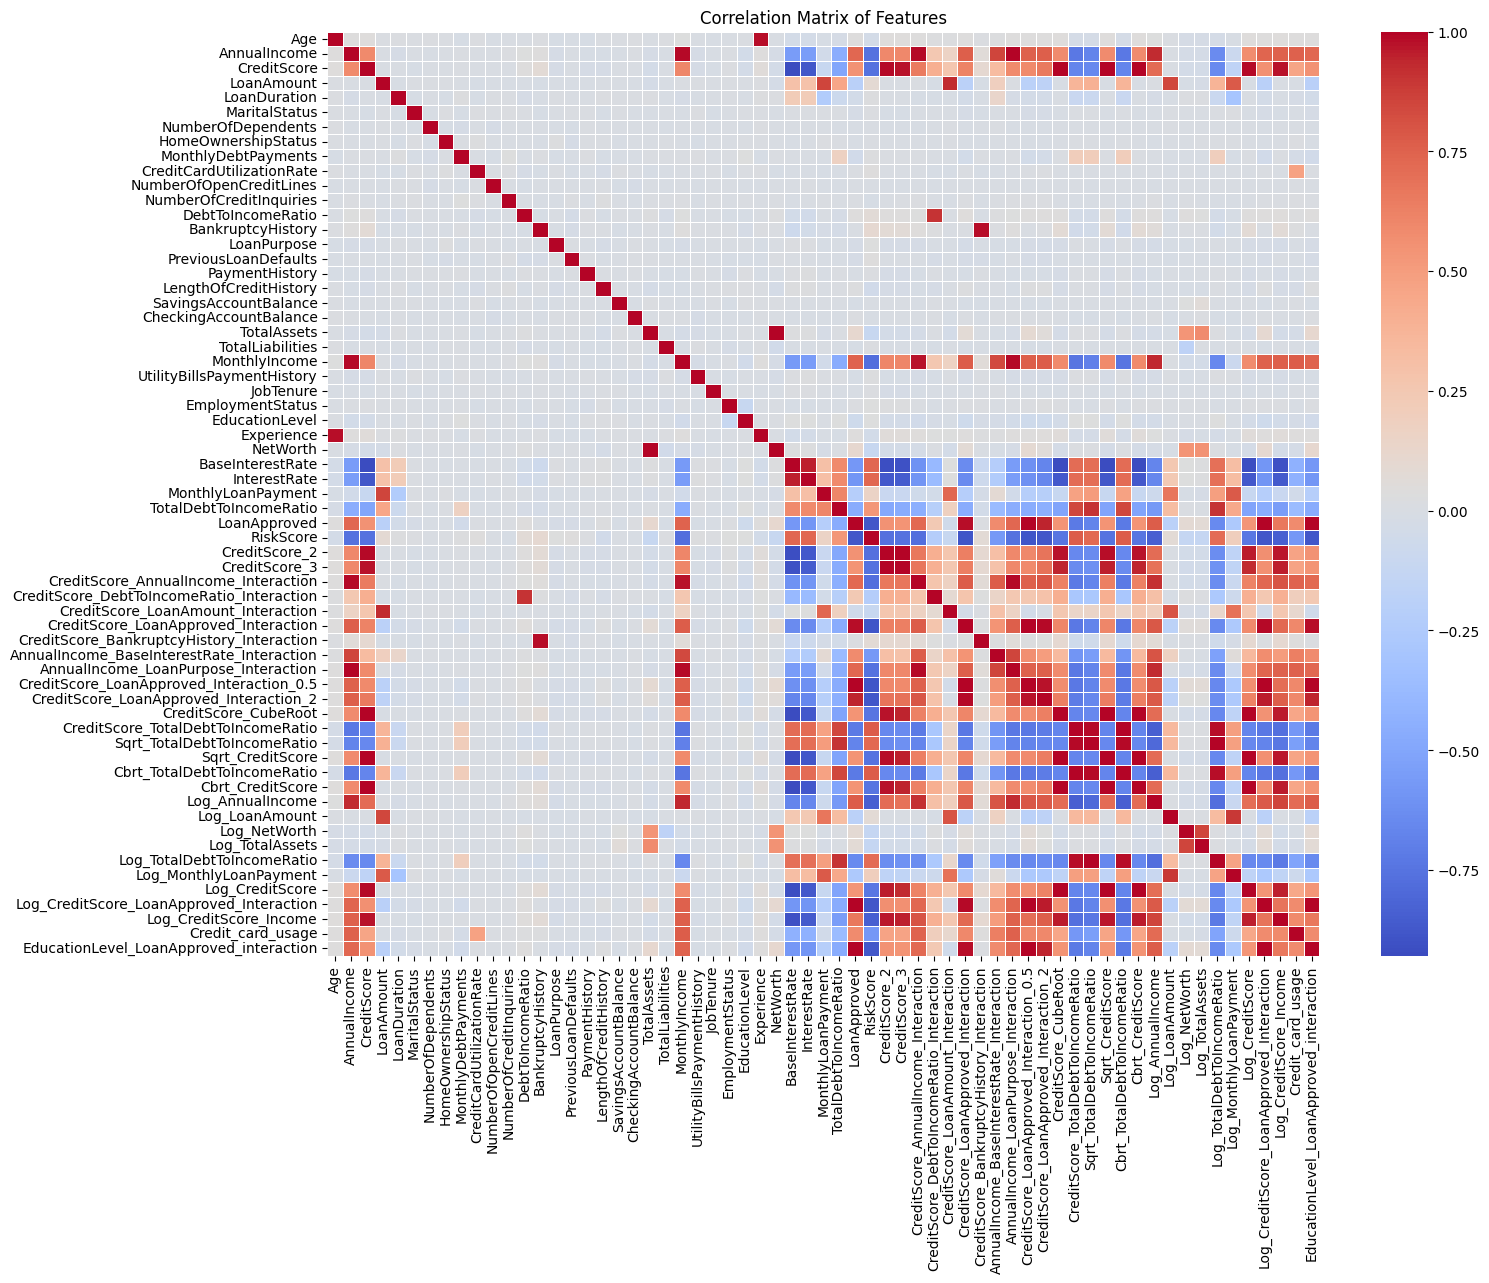

In [51]:
correlation_matrix = df_train.select_dtypes(float).corr()

plt.figure(figsize=(16, 12))

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)

plt.title('Correlation Matrix of Features')
plt.show()

Удалим таргет из выборки

In [52]:
y = df_train['RiskScore']
df_train.drop(['RiskScore', 'UtilityBillsPaymentHistory', 'JobTenure', 'PaymentHistory', 'HomeOwnershipStatus', 'MaritalStatus'], axis=1, inplace=True)
df_test.drop(['UtilityBillsPaymentHistory', 'JobTenure', 'PaymentHistory', 'HomeOwnershipStatus', 'MaritalStatus'], axis=1, inplace=True)

Объявим функции для расчета ошибки

In [53]:
def check_mse(df, target, model):
  predicted_target = model.predict(df)
  return mean_squared_error(predicted_target, target)


def check_mape(df, target, model):
  predicted_target = model.predict(df)
  return mean_absolute_percentage_error(target, predicted_target)


Объявим функцию обучения модели

In [54]:
def fitting(train, target,
            scaler=StandardScaler(),
            model=linear_model.LinearRegression(),
            split_size=0.5,
            split_random_state=89,
            is_split=True):
  pipeline = make_pipeline(scaler, model)

  if is_split:
    train, test, y_train, y_test = train_test_split(train, target, test_size=split_size, random_state=split_random_state)
    pipeline.fit(train, y_train)
    print(f"mse on test: {check_mse(test, y_test, pipeline)},\t mape on test: {check_mape(test, y_test, pipeline)}\nmse on train: {check_mse(train, y_train, pipeline)},\t mape on train: {check_mape(train, y_train, pipeline)}\n-----")
    return pipeline

  pipeline.fit(train, target)
  print(f"DF with columns: \n ---------- \n {train.columns.values}\n ---------- \n with score on train: {check_mse(train, target, pipeline)}")
  return pipeline

Объявим функцию записи предсказания в файл

In [55]:
def write_predict_to_file(path, test, model):
  test_id = test['ID']
  test = test.drop(['ID'], axis=1)
  y_pred = model.predict(test)
  with open(path, 'w') as file:
    file.write("ID,RiskScore\n")
    for id, pred in zip(test_id, y_pred):
      file.write(f"{id},{pred}\n")


In [56]:
def check_predict_distribution(df_train, y, model):
    predicted_y = model.predict(df_train)

    group_labels = ['true_y', 'predicted_y']

    colors = ['slategray', 'magenta']

    fig = ff.create_distplot([y, predicted_y], group_labels, bin_size=.5,
                             colors=colors)

    fig.update_layout(title_text='Distplot with Normal Distribution')
    fig.show(renderer='iframe')

## Тест различных моделей

**Ridge test**

In [57]:
for alpha in [0.8, 0.6, 0.4, 0.2, 0.1]:
  print(f"alpha = {alpha}")
  lr = fitting(df_train, y, scaler=StandardScaler(), model=linear_model.Ridge(alpha=alpha))

alpha = 0.8
mse on test: 11.06264341796405,	 mape on test: 0.05898138056177096
mse on train: 10.942805371304107,	 mape on train: 0.05863190224093941
-----
alpha = 0.6
mse on test: 11.046017808733746,	 mape on test: 0.05890443251019761
mse on train: 10.916220196834425,	 mape on train: 0.05853619727918377
-----
alpha = 0.4
mse on test: 11.030192499494712,	 mape on test: 0.05882590700819173
mse on train: 10.886884978009403,	 mape on train: 0.05843393050517591
-----
alpha = 0.2
mse on test: 11.0080142176022,	 mape on test: 0.05871884430097827
mse on train: 10.846844736068698,	 mape on train: 0.05830388137250251
-----
alpha = 0.1
mse on test: 10.970895972925863,	 mape on test: 0.05859413181048493
mse on train: 10.80168072334985,	 mape on train: 0.05817879358715047
-----


**ElasticNet test**

In [58]:
print("ElasticNet:\n-------")
alpha = [1, 0.8, 0.4, 0.2]
l1_ratio = [0.5, 0.1]
lists = [alpha, l1_ratio]

for alpha, l1_ratio in list(itertools.product(*lists)):
  print(f"alpha = {alpha}\tl1_ratio = {l1_ratio}")
  lr = fitting(df_train, y, scaler=StandardScaler(), model=linear_model.ElasticNet(alpha=alpha, l1_ratio=l1_ratio))

ElasticNet:
-------
alpha = 1	l1_ratio = 0.5
mse on test: 22.66354928932427,	 mape on test: 0.08374513176681903
mse on train: 22.0905691567433,	 mape on train: 0.08170051613989687
-----
alpha = 1	l1_ratio = 0.1
mse on test: 21.58074519739915,	 mape on test: 0.08178263267006797
mse on train: 20.92879648699733,	 mape on train: 0.07962634725052178
-----
alpha = 0.8	l1_ratio = 0.5
mse on test: 20.748260791559495,	 mape on test: 0.07977292879443933
mse on train: 20.18329589132172,	 mape on train: 0.07781502024805648
-----
alpha = 0.8	l1_ratio = 0.1
mse on test: 20.16405472167941,	 mape on test: 0.07875570825422358
mse on train: 19.540889029751284,	 mape on train: 0.0767183800078841
-----
alpha = 0.4	l1_ratio = 0.5
mse on test: 17.08820127199856,	 mape on test: 0.07219503337555898
mse on train: 16.592661555421603,	 mape on train: 0.07065501413204725
-----
alpha = 0.4	l1_ratio = 0.1
mse on test: 17.251204529924458,	 mape on test: 0.07252648255137932
mse on train: 16.744411596721726,	 mape on 

**Lasso Test**


In [59]:
print("Lasso: \n-------")
for alpha in [0.8, 0.6, 0.4, 0.2, 0.1]:
  print(f"alpha = {alpha}")
  lr = fitting(df_train, y, scaler=StandardScaler(), model=linear_model.Lasso(alpha=alpha))

Lasso: 
-------
alpha = 0.8


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.470e+02, tolerance: 1.332e+02



mse on test: 20.38015926012044,	 mape on test: 0.08030079367841632
mse on train: 19.909837629068683,	 mape on train: 0.07831794667484507
-----
alpha = 0.6
mse on test: 17.79205309781416,	 mape on test: 0.07500187791336652
mse on train: 17.360065521408714,	 mape on train: 0.07321581266165605
-----
alpha = 0.4
mse on test: 15.843826137651723,	 mape on test: 0.07083365247892301
mse on train: 15.465056794574295,	 mape on train: 0.0693623113636632
-----
alpha = 0.2
mse on test: 14.092610653807535,	 mape on test: 0.06701664472330708
mse on train: 13.808116701341675,	 mape on train: 0.06591482384868327
-----
alpha = 0.1
mse on test: 13.538175810313158,	 mape on test: 0.065786879106862
mse on train: 13.343725413879183,	 mape on train: 0.06491750829997973
-----


**Huber Regression Test**

In [60]:
print("Huber Regression:\n------- ")
lr = fitting(df_train, y, scaler=StandardScaler(), model=linear_model.HuberRegressor())

Huber Regression:
------- 
mse on test: 11.27589331498742,	 mape on test: 0.059302473554803725
mse on train: 11.084583217134293,	 mape on train: 0.05867850922770722
-----


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html



**Linear Regression Test**

In [61]:
print("Linear Regression:\n------- ")
lr = fitting(df_train, y, scaler=StandardScaler(), model=linear_model.LinearRegression())

Linear Regression:
------- 
mse on test: 9.68888213393717,	 mape on test: 0.055606915256424
mse on train: 9.617368138687324,	 mape on train: 0.05518689755105174
-----


In [62]:
lr = fitting(df_train, y, is_split=False, scaler=StandardScaler(), model=linear_model.LinearRegression())

DF with columns: 
 ---------- 
 ['Age' 'AnnualIncome' 'CreditScore' 'LoanAmount' 'LoanDuration'
 'NumberOfDependents' 'MonthlyDebtPayments' 'CreditCardUtilizationRate'
 'NumberOfOpenCreditLines' 'NumberOfCreditInquiries' 'DebtToIncomeRatio'
 'BankruptcyHistory' 'LoanPurpose' 'PreviousLoanDefaults'
 'LengthOfCreditHistory' 'SavingsAccountBalance' 'CheckingAccountBalance'
 'TotalAssets' 'TotalLiabilities' 'MonthlyIncome' 'EmploymentStatus'
 'EducationLevel' 'Experience' 'NetWorth' 'BaseInterestRate'
 'InterestRate' 'MonthlyLoanPayment' 'TotalDebtToIncomeRatio'
 'LoanApproved' 'CreditScore_2' 'CreditScore_3'
 'CreditScore_AnnualIncome_Interaction'
 'CreditScore_DebtToIncomeRatio_Interaction'
 'CreditScore_LoanAmount_Interaction'
 'CreditScore_LoanApproved_Interaction'
 'CreditScore_BankruptcyHistory_Interaction'
 'AnnualIncome_BaseInterestRate_Interaction'
 'AnnualIncome_LoanPurpose_Interaction'
 'CreditScore_LoanApproved_Interaction_0.5'
 'CreditScore_LoanApproved_Interaction_2' 'CreditS

In [63]:
check_predict_distribution(df_train, y, lr)

In [64]:
write_predict_to_file('/kaggle/working/submission.csv', df_test, lr)